In [11]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, GroupShuffleSplit
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from dotenv import load_dotenv
import time

In [12]:
def sanity_check(name, X, y, groups=None, train_idx=None, test_idx=None):
    print(f"── {name} ──")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}, positive rate: {y.mean():.3f}")
    if groups is not None and train_idx is not None and test_idx is not None:
        tr_groups = set(groups.iloc[train_idx]) if hasattr(groups, 'iloc') else set(groups[train_idx])
        te_groups = set(groups.iloc[test_idx]) if hasattr(groups, 'iloc') else set(groups[test_idx])
        overlap = tr_groups & te_groups
        print(f"  Group overlap: {len(overlap)} statements "
              f"({len(overlap)/max(len(te_groups),1)*100:.1f}% of test groups)")
    print()

In [13]:
load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")

In [14]:
import torch

# 1. Check if CUDA is available
print(f"CUDA Available: {torch.cuda.is_available()}")

# 2. Check CUDA version compiled with PyTorch
print(f"PyTorch CUDA Version: {torch.version.cuda}")

# 3. Count available GPUs
print(f"GPU Count: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    # 4. Get current device index
    print(f"Current Device Index: {torch.cuda.current_device()}")
    
    # 5. Get GPU Name
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    
    # 6. Get GPU Properties (Memory, Compute Capability)
    props = torch.cuda.get_device_properties(0)
    print(f"Total Memory: {props.total_memory / 1024**2:.2f} MB")
    print(f"Compute Capability: {props.major}.{props.minor}")
    
    # 7. Functional Test: Create a tensor on GPU
    try:
        x = torch.rand(5, 3).cuda()
        print(f"Test Tensor on GPU: {x.device}")
    except RuntimeError as e:
        print(f"Runtime Error: {e}")
else:
    print("GPU not available. Ensure NVIDIA drivers and CUDA-enabled PyTorch are installed.")   
    

CUDA Available: True
PyTorch CUDA Version: 12.8
GPU Count: 1
Current Device Index: 0
GPU Name: NVIDIA H200 NVL
Total Memory: 143166.31 MB
Compute Capability: 9.0
Test Tensor on GPU: cuda:0


In [15]:
df = pd.read_csv('Twitter_Analysis.csv', index_col=0)
df.head()

,majority_target,statement,BinaryNumTarget,tweet,followers_count,friends_count,favourites_count,statuses_count,listed_count,following,...,determiners,conjunctions,dots,exclamation,questions,ampersand,capitals,digits,long_word_freq,short_word_freq
0,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders - 6 Month Update\n\nInfl...,4262.0,3619.0,34945.0,16423.0,44.0,0.0,...,0,0,5,0,1,0,33,3,5,19
1,True,End of eviction moratorium means millions of A...,1.0,@S0SickRick @Stairmaster_ @6d6f636869 Not as m...,1393.0,1621.0,31436.0,37184.0,64.0,0.0,...,0,2,1,0,0,0,14,0,2,34
2,True,End of eviction moratorium means millions of A...,1.0,THE SUPREME COURT is siding with super rich pr...,9.0,84.0,219.0,1184.0,0.0,0.0,...,0,1,0,0,0,0,3,0,4,10
3,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders\n\nBroken campaign promi...,4262.0,3619.0,34945.0,16423.0,44.0,0.0,...,0,1,3,0,0,1,6,8,1,30
4,True,End of eviction moratorium means millions of A...,1.0,@OhComfy I agree. The confluence of events rig...,70.0,166.0,15282.0,2194.0,0.0,0.0,...,0,1,3,0,1,0,11,3,2,19


In [16]:
def generate_embeddings(texts: pd.Series, model_name: str) -> np.ndarray:
    print(f"Encoding with {model_name} …")
    model = SentenceTransformer(model_name, device="cuda")
    t0 = time.time()
    embeddings = model.encode(
        texts.tolist(),
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    print(f"  → {embeddings.shape}  ({time.time() - t0:.1f}s)")
    del model
    return embeddings

import os

def get_or_generate_embeddings(texts, model_name, cache_path):
    if os.path.exists(cache_path):
        print(f"Loading cached embeddings from {cache_path}")
        return np.load(cache_path)
    emb = generate_embeddings(texts, model_name)
    np.save(cache_path, emb)
    return emb

X_mpnet = get_or_generate_embeddings(
    df['tweet'], "all-mpnet-base-v2", "emb_mpnet.npy"
)

print(f"MPNet  embeddings: {X_mpnet.shape}")

Loading cached embeddings from emb_mpnet.npy
MPNet  embeddings: (134198, 768)


In [17]:
META_COLUMNS = [
    'mentions', 'replies', 'favourites', 'hashtags', 'URLs',
       'unique_count', 'total_count', 'ORG_percentage', 'NORP_percentage',
       'GPE_percentage', 'PERSON_percentage', 'MONEY_percentage',
       'DATE_percentage', 'CARDINAL_percentage', 'PERCENT_percentage',
       'ORDINAL_percentage', 'FAC_percentage', 'LAW_percentage',
       'PRODUCT_percentage', 'EVENT_percentage', 'TIME_percentage',
       'LOC_percentage', 'WORK_OF_ART_percentage', 'QUANTITY_percentage',
       'LANGUAGE_percentage', 'Word count', 'Max word length',
       'Min word length', 'Average word length', 'present_verbs', 'past_verbs',
       'adjectives', 'adverbs', 'adpositions', 'pronouns', 'TOs',
       'determiners', 'conjunctions', 'dots', 'exclamation', 'questions',
       'ampersand', 'capitals', 'digits', 'long_word_freq', 'short_word_freq'
    ]

X_meta = df[META_COLUMNS].copy()
X_meta = X_meta.apply(pd.to_numeric, errors="coerce").fillna(0)
y = df['BinaryNumTarget'].astype(int)


In [18]:
embedding_cols = [f'emb_{i}' for i in range(X_mpnet.shape[1])]
df_mpnet = pd.DataFrame(X_mpnet, columns=embedding_cols, index=X_meta.index)
X = pd.concat([X_meta, df_mpnet], axis=1)   # or just X_mpnet

In [19]:
embedding_cols = [f'emb_{i}' for i in range(X_mpnet.shape[1])]
df_mpnet = pd.DataFrame(X_mpnet, columns=embedding_cols, index=X_meta.index)
X = pd.concat([X_meta, df_mpnet], axis=1)   # or just X_mpnet

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['statement']))

X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
print(X_tr.shape)

(107930, 814)


In [20]:
# How many unique statements are there vs how many tweets?
print(f"Unique statements: {df['statement'].nunique()}")
print(f"Total tweets: {len(df)}")
print(f"Avg tweets per statement: {len(df) / df['statement'].nunique():.1f}")

# The critical check: do any statements appear in both train and test?
train_statements = set(df.loc[X_tr.index, 'statement'])
test_statements  = set(df.loc[X_te.index, 'statement'])
overlap = train_statements & test_statements
print(f"Statements leaking across train/test: {len(overlap)} "
      f"({len(overlap)/len(test_statements)*100:.1f}% of test statements)")

Unique statements: 1058
Total tweets: 134198
Avg tweets per statement: 126.8
Statements leaking across train/test: 0 (0.0% of test statements)


In [21]:
groups_tr = df.loc[train_idx, 'statement']

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tr2_idx, val_idx = next(gss_val.split(X_tr, y_tr, groups=groups_tr))

X_tr2, X_val = X_tr.iloc[tr2_idx], X_tr.iloc[val_idx]
y_tr2, y_val = y_tr.iloc[tr2_idx], y_tr.iloc[val_idx]

# Sanity check — should print 0
val_statements = set(groups_tr.iloc[val_idx])
tr2_statements = set(groups_tr.iloc[tr2_idx])
print(f"Leaking statements: {len(val_statements & tr2_statements)}")

Leaking statements: 0


## HistGBM Attempt (fail)

In [10]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
model = HistGradientBoostingClassifier(random_state=42, early_stopping=True, validation_fraction=0.1, n_iter_no_change=10)


param_grid = {
    'learning_rate': [0.05, 0.1],       # 0.01 too slow, 1.0 broken
    "max_iter":          [100, 200, 400],    # 100 was still improving
    "max_leaf_nodes":    [63, 127, 255],    # 127 was still improving
    "max_depth":  [10, 20],           # regularization — not yet searched
    "l2_regularization": [0.0, 0.1, 0.5],        # regularization — not yet searched
}


search = GridSearchCV(
    model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    verbose=2,
    n_jobs=-1
)

In [61]:
search.fit(X_tr, y_tr)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


KeyboardInterrupt: 

In [ ]:
# get results of model on validation set
print(f"Best Params: {search.best_params_}")
best_model = search.best_estimator_

from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
y_pred = best_model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))

### XGB?

In [26]:
# 3. XGBoost GPU Configuration
# 'tree_method': 'gpu_hist' is the magic command for Colab GPUs
model = XGBClassifier(
    tree_method='hist', 
    device='cuda',
    random_state=42,
    eval_metric='logloss'
)

# 4. GridSearch Parameters
param_grid = {
    'learning_rate':     [0.03, 0.05, 0.1],
    'n_estimators':      [200, 400],
    'max_depth':         [4, 6, 8],           # pull the ceiling down from 10-12
    'subsample':         [0.7, 0.8],
    'colsample_bytree':  [0.6, 0.8],
    'min_child_weight':  [1, 5, 10],          # NEW — requires more samples per leaf
    'reg_alpha':         [0, 0.1, 1.0],       # NEW — L1 regularization
    'reg_lambda':        [1.0, 5.0, 10.0],    # NEW — L2 regularization
}

cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

print("Starting GPU-accelerated GridSearch...")
search = GridSearchCV(
    model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    verbose=2,
    n_jobs=1 # Keep this 1; the GPU handles the internal parallelism
)

search.fit(X_tr, y_tr, groups=df.loc[train_idx, 'statement'])

Starting GPU-accelerated GridSearch...
Fitting 3 folds for each of 1944 candidates, totalling 5832 fits
[CV] END colsample_bytree=0.6, learning_rate=0.03, max_depth=4, min_child_weight=1, n_estimators=200, reg_alpha=0, reg_lambda=1.0, subsample=0.7; total time=   7.4s


KeyboardInterrupt: 

In [25]:
from sklearn.model_selection import StratifiedGroupKFold
model = XGBClassifier(
    tree_method='hist', 
    device='cuda',
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'learning_rate':     [0.03, 0.05, 0.1],
    'n_estimators':      [200, 400],
    'max_depth':         [4, 6, 8],           # pull the ceiling down from 10-12
    'subsample':         [0.7, 0.8],
    'colsample_bytree':  [0.6, 0.8],
    'min_child_weight':  [1, 5, 10],          # NEW — requires more samples per leaf
    'reg_alpha':         [0, 0.1, 1.0],       # NEW — L1 regularization
    'reg_lambda':        [1.0, 5.0, 10.0],    # NEW — L2 regularization
}
'''
param_grid = {
    'learning_rate':    [0.08, 0.1, 0.12],
    'max_depth':        [7, 8, 9],
    'subsample':        [0.75, 0.8, 0.85],
    'colsample_bytree': [0.75, 0.8, 0.85],
    'min_child_weight': [1, 3, 5],
    'reg_alpha':        [0.5, 1.0, 2.0],
    'reg_lambda':       [3.0, 5.0, 7.0],
    'n_estimators':      [400]
}
'''

cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    model, param_distributions=param_grid,
    n_iter=50,             # ~50 sampled combos instead of 432
    scoring='f1', cv=cv, verbose=2, n_jobs=1, random_state=42
)
search.fit(X_tr, y_tr, groups=df.loc[train_idx, 'statement'])

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, min_child_weight=10, n_estimators=400, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7; total time=  23.6s


KeyboardInterrupt: 

In [31]:
import time
model = XGBClassifier(
    tree_method='hist', 
    device='cuda',
    random_state=42,
    eval_metric='logloss',
    max_depth=4,
    n_estimators=200
)
s = time.time()
model.fit(X_tr, y_tr)
print(time.time() - s)

6.531949520111084


## XGB on just metadata 
(data different than preprocessing from above, use `X[META_COLUMNS]`)

In [78]:
from sklearn.model_selection import train_test_split

X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=42
)

model = XGBClassifier(
    tree_method='hist', device='cuda', random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=30,
    **search.best_params_
)
model.fit(
    X_tr2, y_tr2,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print(f"Best iteration: {model.best_iteration}")

Best iteration: 398


In [ ]:
# get results of model on validation set
print(f"Best Params: {search.best_params_}")
best_model = search.best_estimator_
#best_model = joblib.load('social_model_xgboost.joblib')

from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
y_pred = best_model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, best_model.predict_proba(X_val)[:, 1]))

[[6566 1273]
 [1436 6915]]


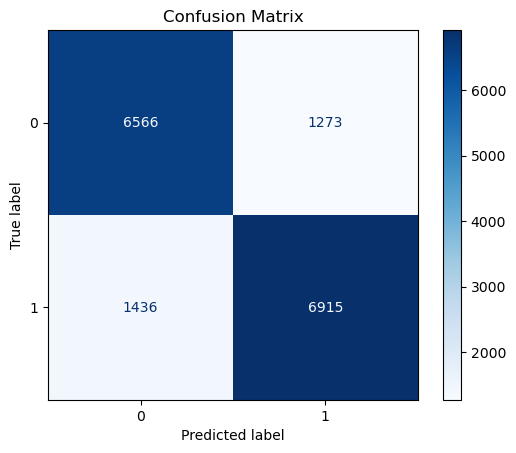

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cf = confusion_matrix(y_val, y_pred)
print(cf)
disp = ConfusionMatrixDisplay(cf)

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [81]:
# get results of model on validation set
y_pred_tr = best_model.predict(X_tr)
print("Accuracy:", accuracy_score(y_tr, y_pred_tr))
print("F1 Score:", f1_score(y_tr, y_pred_tr))
print("Precision:", precision_score(y_tr, y_pred_tr))
print("Recall:", recall_score(y_tr, y_pred_tr))
print(classification_report(y_tr, y_pred_tr))
print("ROC AUC:", roc_auc_score(y_tr, best_model.predict_proba(X_tr)[:, 1]))

Accuracy: 0.8361901232280181
F1 Score: 0.8399188729129695
Precision: 0.8467731629392972
Recall: 0.833174657349692
              precision    recall  f1-score   support

           0       0.83      0.84      0.83     52261
           1       0.85      0.83      0.84     55669

    accuracy                           0.84    107930
   macro avg       0.84      0.84      0.84    107930
weighted avg       0.84      0.84      0.84    107930

ROC AUC: 0.9201158882477998


[[43868  8393]
 [ 9287 46382]]


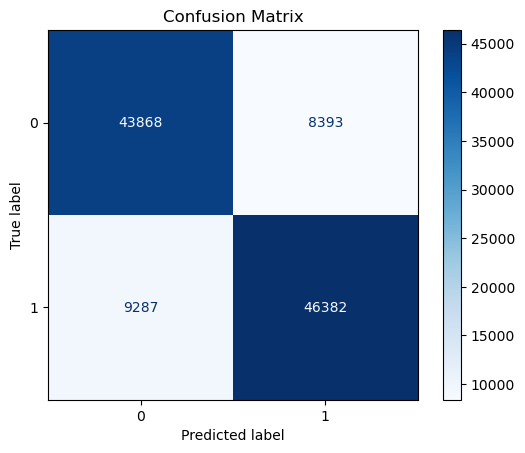

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cf = confusion_matrix(y_tr, y_pred_tr)
print(cf)
disp = ConfusionMatrixDisplay(cf)

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [83]:
joblib.dump(best_model, 'social_model_xgboost.joblib', compress=3)

['social_model_xgboost.joblib']

## XGB with embeddings

In [24]:
# Reconstruct the winning config exactly
best_params = {
    'learning_rate': 0.06,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 0.75,
    'reg_alpha': 0.5,
    'reg_lambda': 3.0,
}

# Step 1: confirm best_iteration on X_tr2/X_val (should land near 238 again,
# small variance expected due to any nondeterminism in your data pipeline)
from xgboost.callback import EarlyStopping
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score


es = EarlyStopping(rounds=40, min_delta=1e-5, save_best=True,
                    maximize=False, metric_name="logloss")

probe = XGBClassifier(tree_method="hist", device="cuda", random_state=42,
                       eval_metric="logloss", n_estimators=800,
                       callbacks=[es], **best_params)
probe.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)
print(f"Best iteration: {probe.best_iteration}")

# Step 2: retrain on FULL X_tr with the 1.1x margin — this is the step
# that likely differs from your recent run
final_n_estimators = int(probe.best_iteration * 1.1)
final_model = XGBClassifier(tree_method="hist", device="cuda", random_state=42,
                             eval_metric="logloss",
                             n_estimators=final_n_estimators, **best_params)
final_model.fit(X_tr, y_tr)   # note: X_tr, not X_tr2 — uses all training data

# Step 3: evaluate on X_te exactly as before
y_pred = final_model.predict(X_te)
y_proba = final_model.predict_proba(X_te)[:, 1]
print("Accuracy:", accuracy_score(y_te, y_pred))
print("ROC AUC:", roc_auc_score(y_te, y_proba))
print("F1 Score:", f1_score(y_te, y_pred))
print("Precision:", precision_score(y_te, y_pred))
print("Recall:", recall_score(y_te, y_pred))
print(classification_report(y_te, y_pred))

Best iteration: 238
Accuracy: 0.8123572407492006
ROC AUC: 0.8914004395271269
F1 Score: 0.8125926770845215
Precision: 0.819478527607362
Recall: 0.8058215820827992
              precision    recall  f1-score   support

           0       0.81      0.82      0.81     13007
           1       0.82      0.81      0.81     13261

    accuracy                           0.81     26268
   macro avg       0.81      0.81      0.81     26268
weighted avg       0.81      0.81      0.81     26268



[[10653  2354]
 [ 2575 10686]]


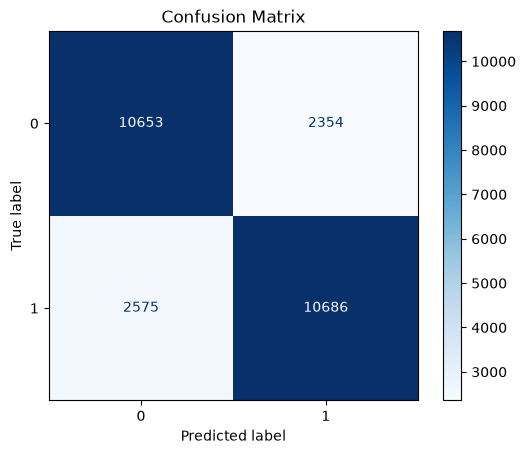

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cf = confusion_matrix(y_te, y_pred)
print(cf)
disp = ConfusionMatrixDisplay(cf)

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [27]:
"""
final_cv_confirmation_and_export.py
-------------------------------------
1. 5-fold StratifiedGroupKFold on the winning config — get a trustworthy
   mean ± std AUC to report, rather than trusting a single split.
2. Save the final model + all artifacts needed for production inference.
"""

import numpy as np
import pandas as pd
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

# ══════════════════════════════════════════════════════════════════════
# 1. Confirmatory 5-fold StratifiedGroupKFold
#    Run on the FULL dataset (X = metadata + mpnet, all rows), grouped
#    by statement, to get a stable estimate of true generalization.
# ══════════════════════════════════════════════════════════════════════

best_params = {
    'learning_rate': 0.06,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 0.75,
    'reg_alpha': 0.5,
    'reg_lambda': 3.0,
}
N_ESTIMATORS = 261   # from the confirmed best_iteration * 1.1 margin

# X_full: full combined feature matrix (metadata + mpnet), all 134,198 rows
# y_full: full label vector
# groups_full: df['statement'] for all rows
X_full = X.copy()
y_full = y.copy()
groups_full = df['statement']

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
for fold, (train_idx_cv, test_idx_cv) in enumerate(
    cv.split(X_full, y_full, groups=groups_full)
):
    model = XGBClassifier(
        tree_method="hist", device="cuda", random_state=42,
        eval_metric="logloss", n_estimators=N_ESTIMATORS, **best_params,
    )
    model.fit(X_full.iloc[train_idx_cv], y_full.iloc[train_idx_cv])

    proba = model.predict_proba(X_full.iloc[test_idx_cv])[:, 1]
    preds = model.predict(X_full.iloc[test_idx_cv])

    fold_auc = roc_auc_score(y_full.iloc[test_idx_cv], proba)
    fold_acc = accuracy_score(y_full.iloc[test_idx_cv], preds)
    fold_f1  = f1_score(y_full.iloc[test_idx_cv], preds)

    fold_results.append({"fold": fold, "auc": fold_auc, "acc": fold_acc, "f1": fold_f1})
    print(f"Fold {fold}: AUC={fold_auc:.4f}  Acc={fold_acc:.4f}  F1={fold_f1:.4f}")

results_df = pd.DataFrame(fold_results)
print(f"\nMean AUC: {results_df['auc'].mean():.4f} ± {results_df['auc'].std():.4f}")
print(f"Mean Acc: {results_df['acc'].mean():.4f} ± {results_df['acc'].std():.4f}")
print(f"Mean F1:  {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")

# ══════════════════════════════════════════════════════════════════════
# 2. Train the FINAL model on ALL available data (not just X_tr) —
#    for shipping, use every labeled row you have; the CV above already
#    gave you the honest generalization estimate, so this last model
#    doesn't need a held-out test set anymore.
# ══════════════════════════════════════════════════════════════════════

production_model = XGBClassifier(
    tree_method="hist", device="cuda", random_state=42,
    eval_metric="logloss", n_estimators=N_ESTIMATORS, **best_params,
)
production_model.fit(X_full, y_full)

# ══════════════════════════════════════════════════════════════════════
# 3. Save all production artifacts
# ══════════════════════════════════════════════════════════════════════

FEATURE_COLUMNS = META_COLUMNS + [f"emb_{i}" for i in range(768)]  # mpnet dim

joblib.dump(production_model, "social_model.joblib")
joblib.dump(FEATURE_COLUMNS, "social_model_columns.joblib")

# Also save the exact hyperparameters + CV results as a metadata record
model_card = {
    "params": {**best_params, "n_estimators": N_ESTIMATORS},
    "embedding_model": "all-mpnet-base-v2",
    "embedding_dim": 768,
    "cv_mean_auc": float(results_df["auc"].mean()),
    "cv_std_auc": float(results_df["auc"].std()),
    "cv_mean_acc": float(results_df["acc"].mean()),
    "feature_count": len(FEATURE_COLUMNS),
    "n_statements": int(groups_full.nunique()),
    "n_samples": int(len(y_full)),
}
joblib.dump(model_card, "social_model_card.joblib")
print("\nSaved: social_model.joblib, social_model_columns.joblib, social_model_card.joblib")

Fold 0: AUC=0.8485  Acc=0.7869  F1=0.7928
Fold 1: AUC=0.9065  Acc=0.8310  F1=0.8357
Fold 2: AUC=0.8969  Acc=0.8075  F1=0.8214
Fold 3: AUC=0.8353  Acc=0.7570  F1=0.7641
Fold 4: AUC=0.8770  Acc=0.8075  F1=0.8186

Mean AUC: 0.8729 ± 0.0305
Mean Acc: 0.7980 ± 0.0277
Mean F1:  0.8065 ± 0.0283

Saved: social_model.joblib, social_model_columns.joblib, social_model_card.joblib
